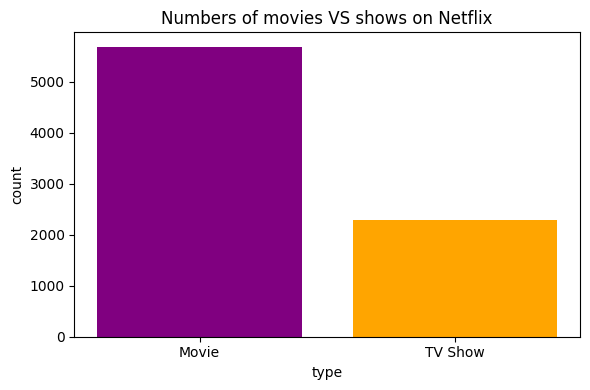

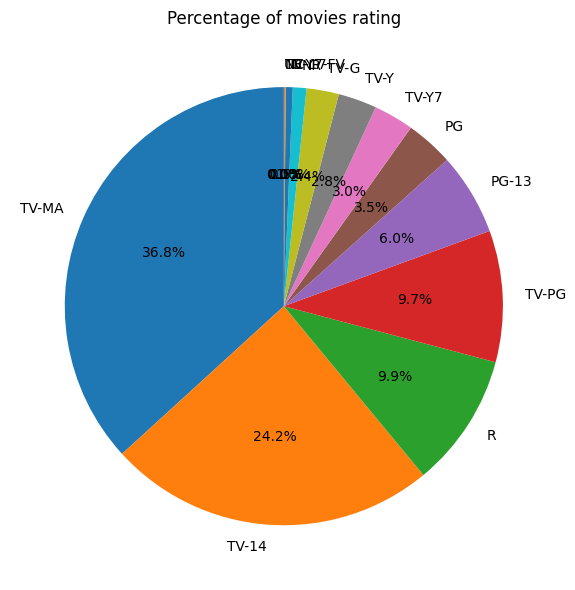

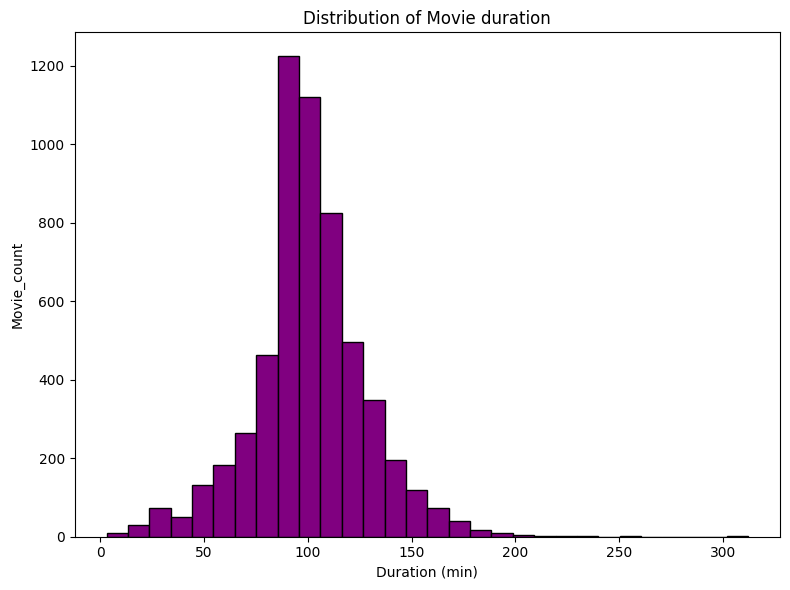

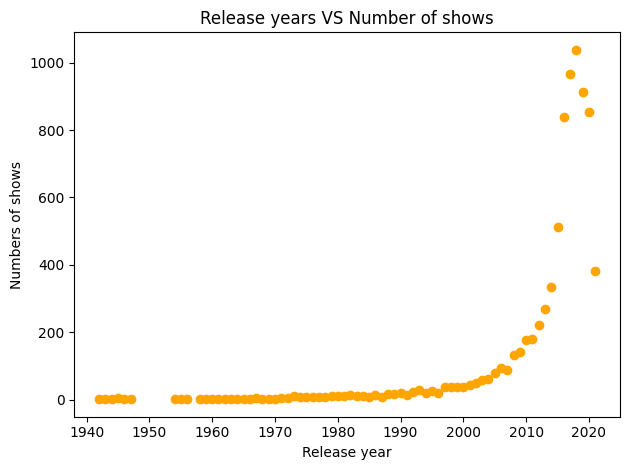

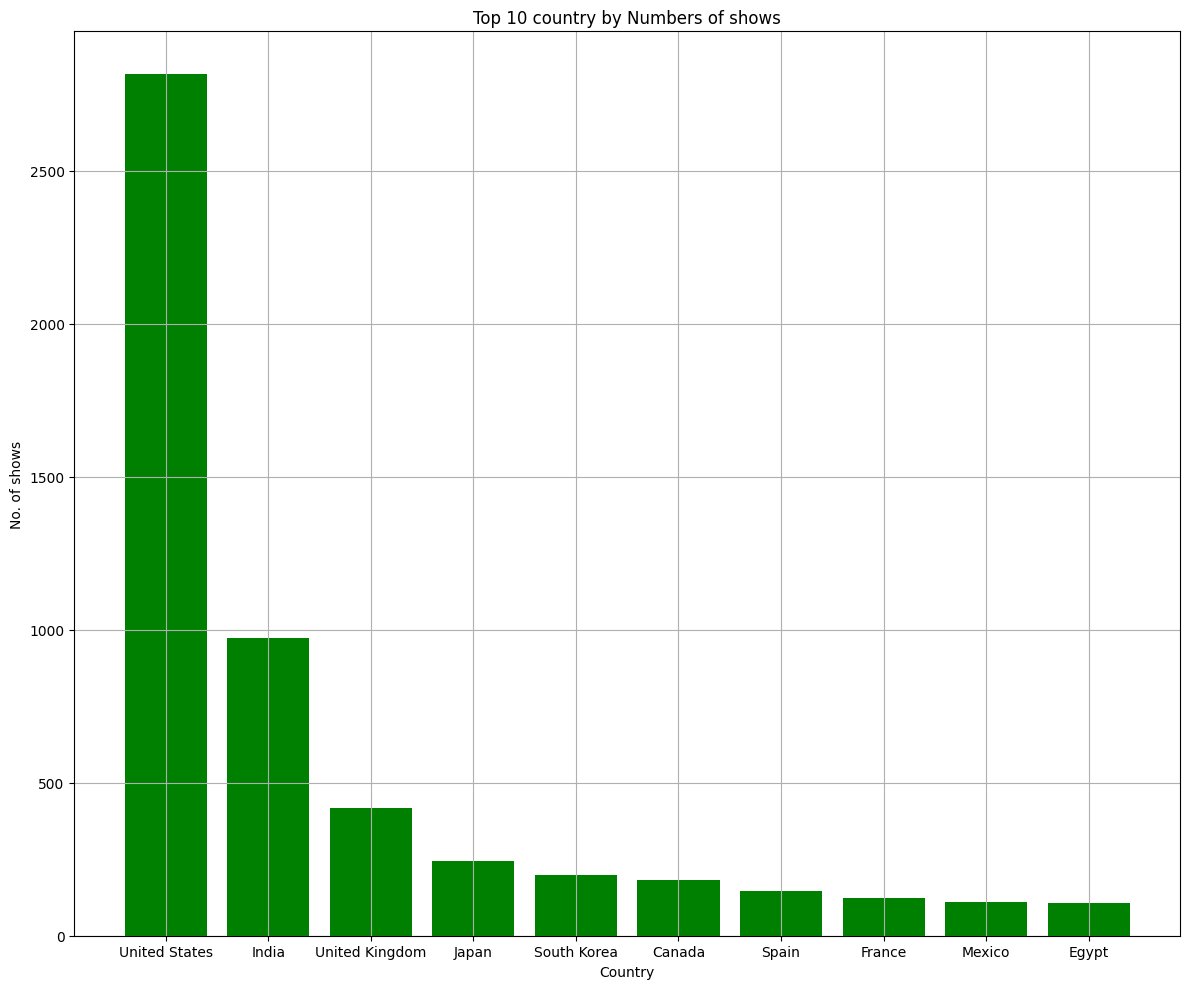

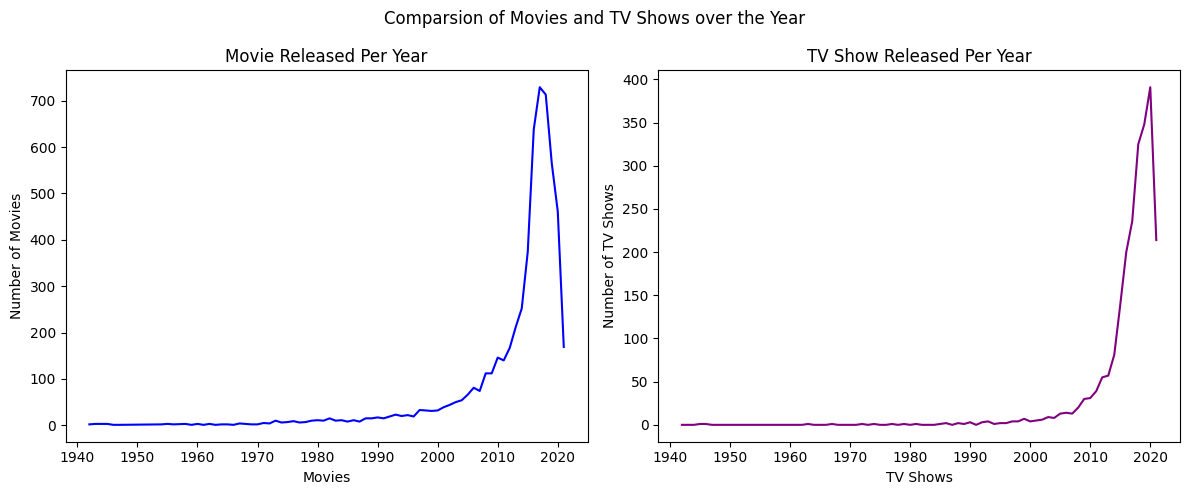

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

#load data
df=pd.read_csv('/home/naman/Desktop/netflix-data-exploration/data/netflix_titles.csv')

#clean data
df = df.dropna(subset=['type','release_year','rating','country','duration'])

type_count = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_count.index,type_count.values,color =['purple','orange'])
plt.title("Numbers of movies VS shows on Netflix")
plt.xlabel("type")
plt.ylabel("count")
plt.tight_layout()
plt.savefig('/home/naman/Desktop/netflix-data-exploration/images/movies_vs_shows.png')
plt.show()



rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels = rating_counts.index,autopct='%1.1f%%',startangle=90)
plt.title("Percentage of movies rating")
plt.tight_layout()
plt.savefig('/home/naman/Desktop/netflix-data-exploration/images/Content_rating_pie.png')
plt.show()


movie_df = df[df['type']=='Movie'].copy()
movie_df['duration_int']=movie_df['duration'].str.replace(' min',' ').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color='purple',edgecolor="black")
plt.title("Distribution of Movie duration")
plt.xlabel("Duration (min)")
plt.ylabel("Movie_count")
plt.tight_layout()
plt.savefig('/home/naman/Desktop/netflix-data-exploration/images/movies_duration.png')
plt.show()


release_count =df['release_year'].value_counts().sort_index()
plt.Figure(figsize=(8,10))
plt.scatter(release_count.index ,release_count.values ,color = "orange")
plt.title("Release years VS Number of shows")
plt.xlabel("Release year")
plt.ylabel("Numbers of shows")
plt.tight_layout()
plt.savefig('/home/naman/Desktop/netflix-data-exploration/images/Release_year_VS_no_of_show.png')
plt.show()



country_count = df['country'].value_counts().head(10)
plt.figure(figsize=(12,10))
plt.bar(country_count.index , country_count.values , color="green")
plt.title("Top 10 country by Numbers of shows")
plt.xlabel("Country")
plt.ylabel("No. of shows")
plt.tight_layout()
plt.savefig('/home/naman/Desktop/netflix-data-exploration/images/top10_country_by_show.png')
plt.grid(True)
plt.show()

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)


fig, ax = plt.subplots(1,2, figsize=(12,5))


#first subplot:movies
ax[0].plot(content_by_year.index, content_by_year['Movie'],color ="blue")
ax[0].set_title("Movie Released Per Year")
ax[0].set_xlabel("Movies")
ax[0].set_ylabel("Number of Movies")



#subplot subplot:tv show
ax[1].plot(content_by_year.index, content_by_year['TV Show'],color ="purple")
ax[1].set_title("TV Show Released Per Year")
ax[1].set_xlabel("TV Shows")
ax[1].set_ylabel("Number of TV Shows")

fig.suptitle("Comparsion of Movies and TV Shows over the Year")
plt.tight_layout()
plt.savefig("/home/naman/Desktop/netflix-data-exploration/images/Movies_tv_shows_Comparsion")
plt.show()

